In [1]:
!pip install xgboost catboost
!pip install imbalanced-learn

In [2]:
# Importamos las librerias necesarias para analizar el dataset de diabetes:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,      # ← Esta te falta
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.tree import plot_tree
%matplotlib inline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay


# Para manejar el desbalanceo
from imblearn.over_sampling import SMOTE

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


# Modelos que requieren normalización
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Modelos basados en árboles
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

# Para evitar warnings innecesarios
import warnings
warnings.filterwarnings('ignore')


In [3]:
data=pd.read_csv('diabetes.csv')
data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
# La base de datos tiene 253.680 registros y 22 variables.
data.shape

(253680, 22)

In [5]:
# Para describir los datos
data.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [6]:
#informacion del dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
#  Una forma más facil de hacer lo de debajo:

# 1. Pasamos TODAS las columnas a entero primero (para limpiar todo de golpe)
data = data.astype(int)

# 2. Convertimos SOLO el BMI a float como tú prefieres
data['BMI'] = data['BMI'].astype(float)

In [8]:
# Como no sé muy bien si el BMI ponerlo entero o float los he puesto todos uno a uno
data['Diabetes_binary'] = data['Diabetes_binary'].astype(int)
data['HighBP'] = data['HighBP'].astype(int)
data['HighChol'] = data['HighChol'].astype(int)
data['CholCheck'] = data['CholCheck'].astype(int)
data['BMI'] = data['BMI'].astype(int)
data['Smoker'] = data['Smoker'].astype(int)
data['Stroke'] = data['Stroke'].astype(int)
data['HeartDiseaseorAttack'] = data['HeartDiseaseorAttack'].astype(int)
data['PhysActivity'] = data['PhysActivity'].astype(int)
data['Fruits'] = data['Fruits'].astype(int)
data['Veggies'] = data['Veggies'].astype(int)
data['HvyAlcoholConsump'] = data['HvyAlcoholConsump'].astype(int)
data['AnyHealthcare'] = data['AnyHealthcare'].astype(int)
data['NoDocbcCost'] = data['NoDocbcCost'].astype(int)
data['GenHlth'] = data['GenHlth'].astype(int)
data['MentHlth'] = data['MentHlth'].astype(int)
data['PhysHlth'] = data['PhysHlth'].astype(int)
data['DiffWalk'] = data['DiffWalk'].astype(int)
data['Sex'] = data['Sex'].astype(int)
data['Age'] = data['Age'].astype(int)
data['Education'] = data['Education'].astype(int)
data['Income'] = data['Income'].astype(int)

In [9]:
# Quiero pasar todos los registros a enteros para que 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_binary       253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-n

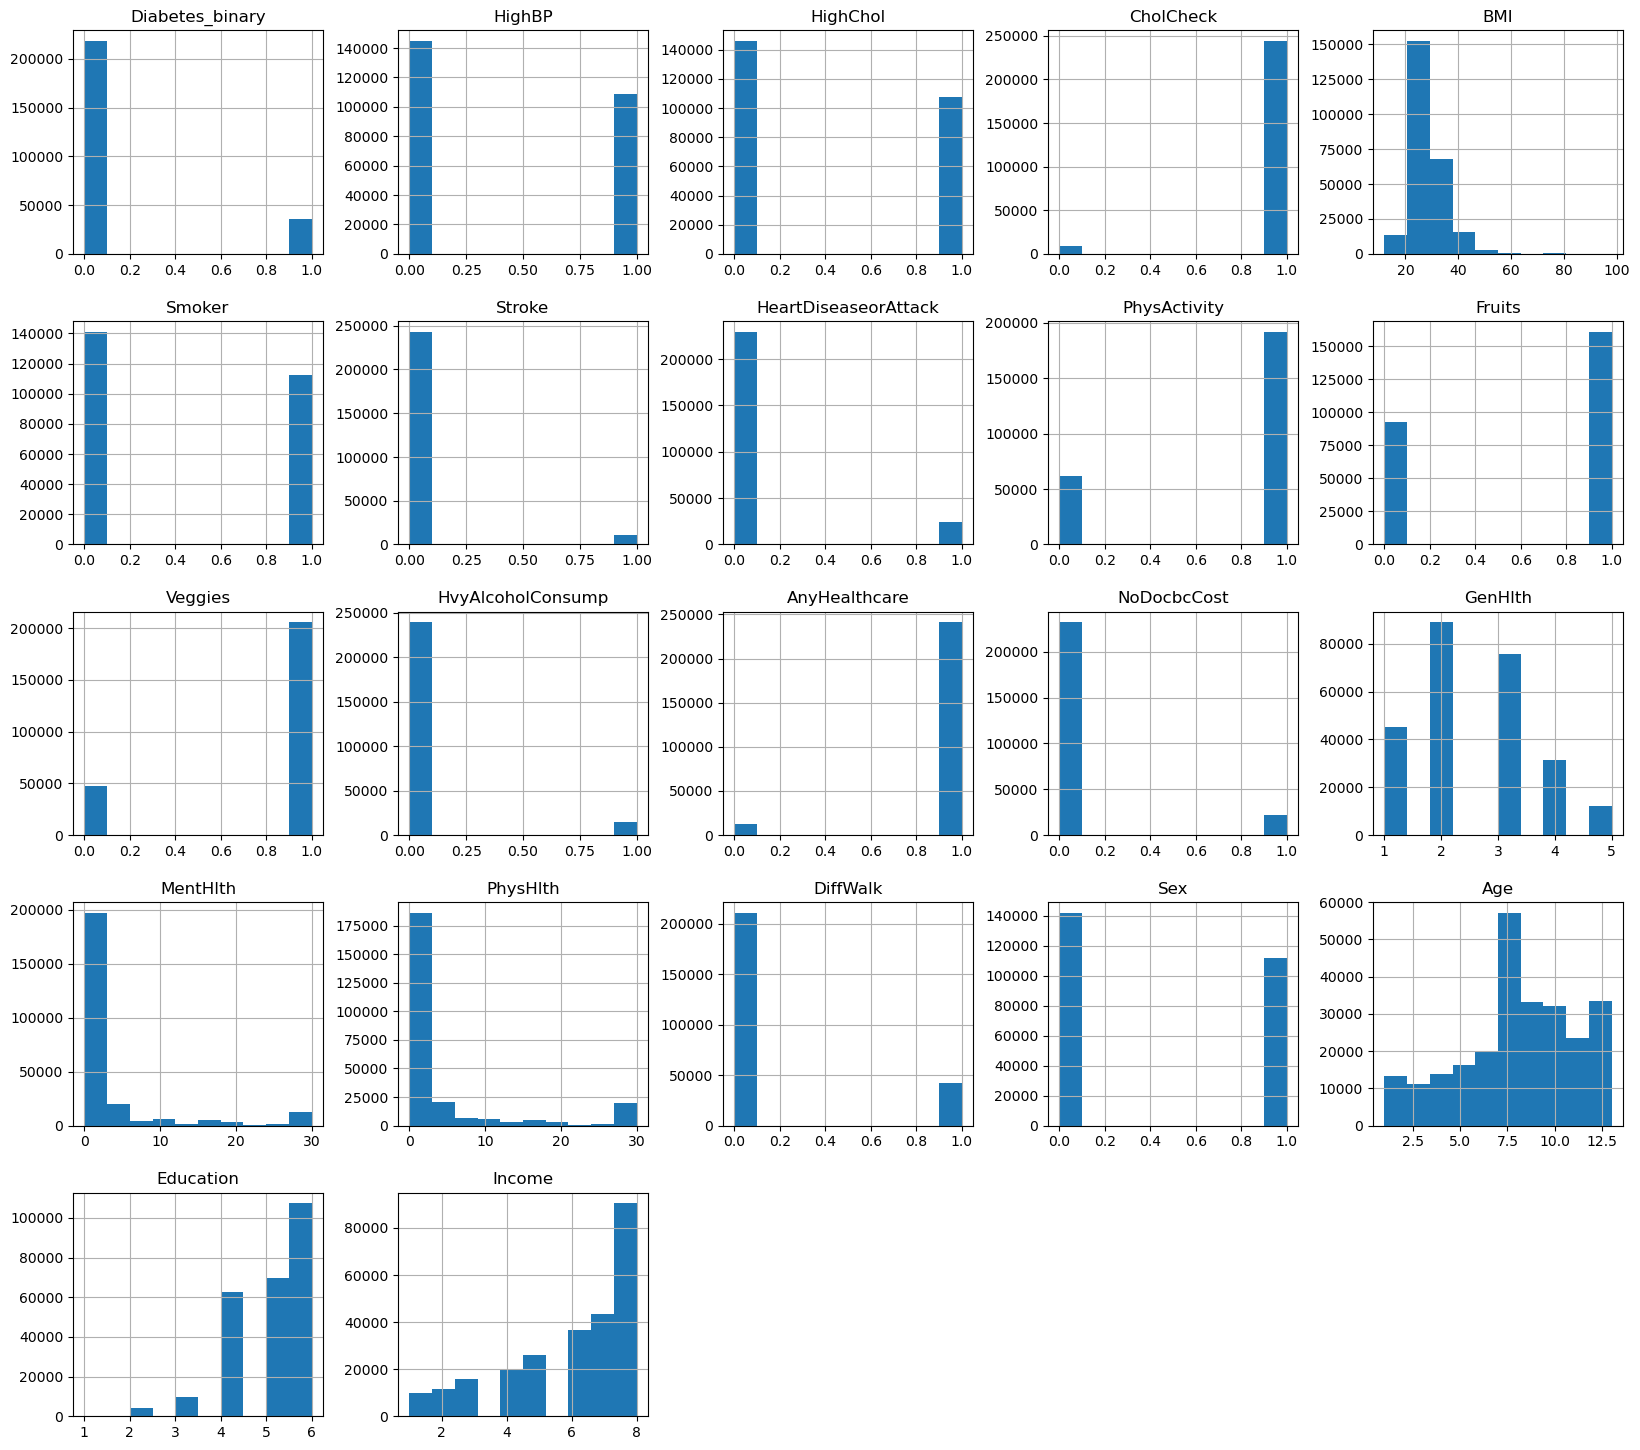

In [10]:
# Histograma de todas las variables de la base de datos:
data.hist(bins=10,figsize=(20,18))
plt.show()

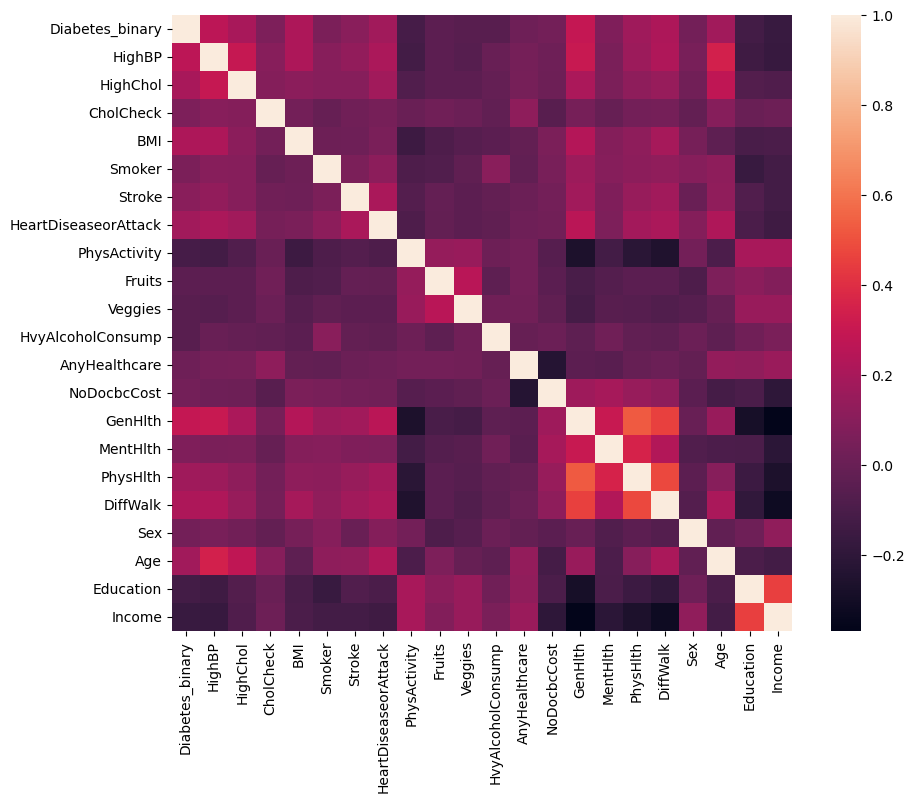

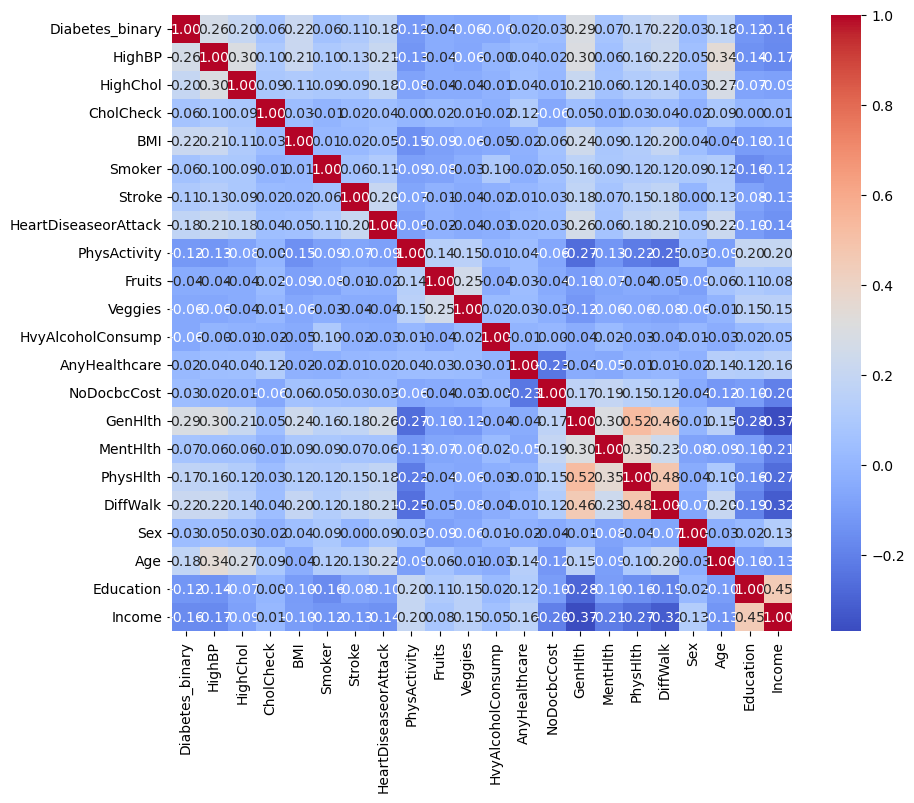

In [11]:
#correlation
# Ajustar el tamaño del lienzo
plt.figure(figsize=(10, 8))

sns.heatmap(data.corr())

# Mostrar ambos gráficos
plt.show()

# Para que el segundo grafico no salga con esos colores tan oscuros como 

plt.figure(figsize=(10, 8))

# 1. Tu primera matriz (Con números y colores coolwarm)
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")

# Mostrar ambos gráficos
plt.show()
# ANÁLISIS DEL MAPA DE COLOR DE CORRELACIONES (CORRELATION HEATMAP): 
# Podemos ver que los colores más rosaceos son los que más correlación tienen con la otra variable, entonces vamos a mirar la primera fila que es la 
# de diabetes_binary y vamos a ver en que variables es más clara. 
# 1.HighBP (Presión arterial alta):  De los más claritos, hay una relación directa muy clara entre hipertensión y diabetes.
# 2.GenHlth (Salud general percibida): Los pacientes que se sienten peor de salud general tienen más correlación con la diabetes.
# 3.BMI (Indice de Masa Corporal): A mayor peso/obesidad, mayor presencia de diabetes.
# 4.HighChol (Colesterol alto) y DiffWalk (Dificultad para caminar): Tambien muestran tonos notablemente más claros.

In [12]:
print("--- CONTEO TOTAL DE PACIENTES ---")
# 1. Cuenta cuántos registros reales hay de cada tipo
conteo_absoluto = data["Diabetes_binary"].value_counts()
print(conteo_absoluto)

print("\n--- PORCENTAJE DE CADA CLASE (%) ---")
# 2. Calcula el porcentaje exacto (ideal para escribir en el texto del TFM)
conteo_porcentaje = data["Diabetes_binary"].value_counts(normalize=True) * 100
print(conteo_porcentaje.round(2))

--- CONTEO TOTAL DE PACIENTES ---
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

--- PORCENTAJE DE CADA CLASE (%) ---
Diabetes_binary
0    86.07
1    13.93
Name: proportion, dtype: float64


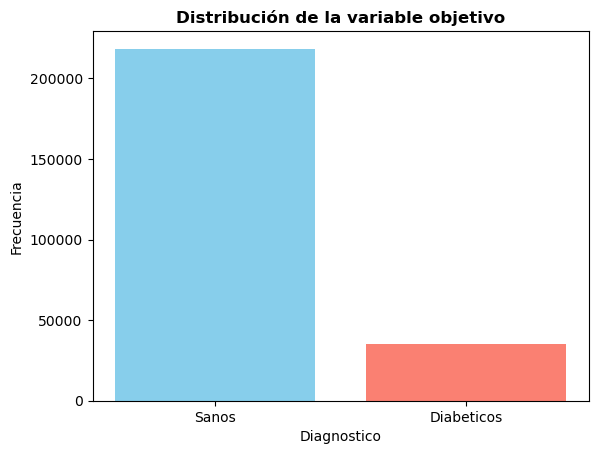

In [13]:
# De esta forma dibujamos en un grafico los sanos y los diabeticos.
X = data.drop("Diabetes_binary", axis=1)
y = data["Diabetes_binary"]

plt.bar(y.value_counts().index, y.value_counts().values, color=['skyblue','salmon'])
plt.xticks([0,1], ['Sanos', 'Diabeticos'])
plt.ylabel("Frecuencia")
plt.xlabel("Diagnostico")
plt.title("Distribución de la variable objetivo", fontweight='bold')
plt.show()

PREPROCESAMIENTO

In [14]:
!pip install imbalanced-learn

In [15]:
# 1. IMPORTAR LAS FUNCIONES QUE FALTAN
from sklearn.model_selection import train_test_split
from collections import Counter

X = data.drop(columns=['Diabetes_binary'])
y = data['Diabetes_binary']

# Dividimos en Train (80%) y Test (20%) manteniendo la proporción original mediante 'stratify'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Distribución original en el set de entrenamiento:")
# De esta forma vemos los valores de la variable objetivo de la muestra de entrenamiento
print(Counter(y_train))

Distribución original en el set de entrenamiento:
Counter({0: 174667, 1: 28277})


In [16]:
# Ahora se procede a normalizar los datos.
from sklearn.preprocessing import StandardScaler
# Utilizando Standard Scaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.utils import class_weight

Diabetes_binary
0    174667
1     28277
Name: count, dtype: int64
{np.int64(0): np.float64(0.5809447910082717), np.int64(1): np.float64(3.5885248684433884)}
[101471.88381104 101472.71770497]


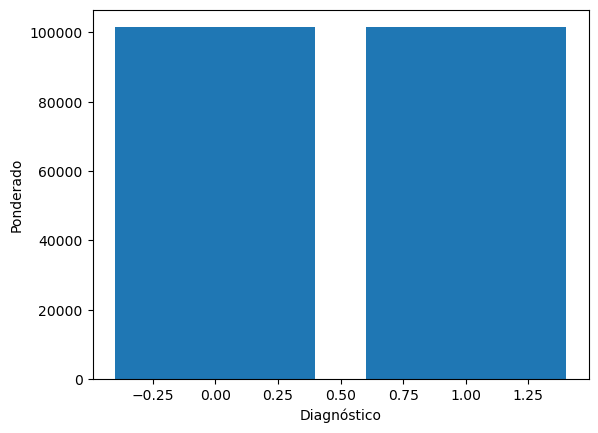

In [18]:
# Calculamos el máximo y mínimo
maxs = np.max(X_train, axis=0)
mins = np.min(X_train, axis=0)

ranges = maxs - mins

# Normalizamos las variables
x_train = (X_train - mins) / ranges
x_test = (X_test - mins) / ranges

# Calcula las frecuencias de clase en y_train
class_frequencies = y_train.value_counts()

# Calcula los pesos para cada clase  
#class_weights = {cls: 1.0 / freq for cls, freq in class_frequencies.items()}
#class_weights_int = {int(cls[0]): weight for cls, weight in class_weights.items()}

# Calcula los pesos de clase
class_weights = class_weight.compute_class_weight('balanced', classes=y.unique(), y=y)

# Crea un diccionario con los pesos de clase
class_weights_int = {cls: weight for cls, weight in zip(y.unique(), class_weights)}
print(class_frequencies)
print(class_weights_int)

pesos_ordenados=[]
for i in range(2):
    peso=class_weights_int[i]
    pesos_ordenados.append(peso)
print(class_frequencies.values * pesos_ordenados)
# Crea un gráfico de barras para visualizar la frecuencia ponderada de los valores de clase
plt.bar(class_frequencies.index, class_frequencies.values * pesos_ordenados)
plt.xlabel('Diagnóstico')
plt.ylabel('Ponderado')
plt.show()

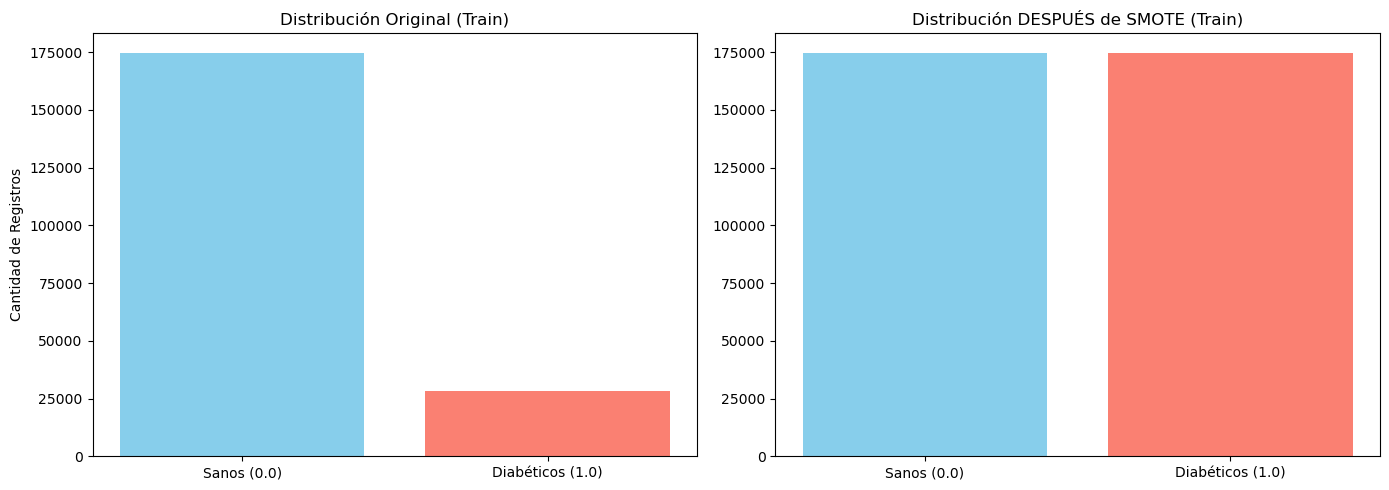

In [19]:
# ==========================================
# PASO 1: Aplicar SMOTE y Graficar Distribución
# ==========================================
# Configurar SMOTE según la guía (parámetro 'minority')
# La función SMOTE busca cuál es la clase que tiene menos datos (la minoritaria, que en tu caso son los enfermos de diabetes) y genera datos nuevos
# de esa clase hasta que iguale en cantidad a la clase mayoritaria (los sanos)
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Crear gráfica comparativa antes y después para ver la diferencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica Antes
axes[0].bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue', 'salmon'])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Sanos (0.0)', 'Diabéticos (1.0)'])
axes[0].set_title("Distribución Original (Train)")
axes[0].set_ylabel("Cantidad de Registros")

# Gráfica Después
axes[1].bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, color=['skyblue', 'salmon'])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Sanos (0.0)', 'Diabéticos (1.0)'])
axes[1].set_title("Distribución DESPUÉS de SMOTE (Train)")

plt.tight_layout()
plt.show()

In [20]:
print("--- REGISTROS ANTES DE SMOTE ---")
print(pd.Series(y_train).value_counts())
print(f"Total registros entrenamiento original: {len(y_train)}\n")

print("--- REGISTROS DESPUÉS DE SMOTE ---")
print(pd.Series(y_train_sm).value_counts())
print(f"Total registros entrenamiento post-SMOTE: {len(y_train_sm)}")

--- REGISTROS ANTES DE SMOTE ---
Diabetes_binary
0    174667
1     28277
Name: count, dtype: int64
Total registros entrenamiento original: 202944

--- REGISTROS DESPUÉS DE SMOTE ---
Diabetes_binary
0    174667
1    174667
Name: count, dtype: int64
Total registros entrenamiento post-SMOTE: 349334


In [21]:
# Voy a unir primero los dos objetos: X_train_sm y y_train_sm en uno: train_smote_df
train_smote_df = pd.concat([X_train_sm, y_train_sm], axis=1)

In [22]:
train_smote_df.to_csv("obesidad_py.csv", index=False)

## MODELOS

### MODELOS BASADOS EN ARBOLES (NO NECESITAN NORMALIZACIÓN)

### ÁRBOL DE DECISIÓN

              precision    recall  f1-score   support

           0       0.89      0.79      0.84     43667
           1       0.24      0.42      0.31      7069

    accuracy                           0.74     50736
   macro avg       0.57      0.61      0.57     50736
weighted avg       0.80      0.74      0.76     50736

Accuracy: 0.7371097445600757
cross_value:  0.830477703213105


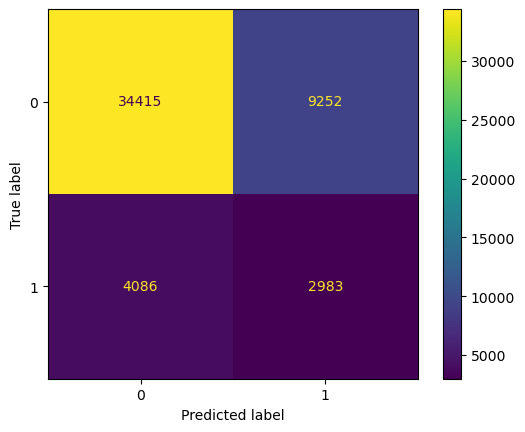

Accuracy: 0.7371097445600757

Matriz de confusión:
[[34415  9252]
 [ 4086  2983]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84     43667
           1       0.24      0.42      0.31      7069

    accuracy                           0.74     50736
   macro avg       0.57      0.61      0.57     50736
weighted avg       0.80      0.74      0.76     50736



In [26]:
print("\nEntrenando Árbol de Decisión...")
# ==============================
# 1. Crear el modelo definiendo sus 
# ==============================
modelo_arbol = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=42
)
# Con max_depth=None, el árbol sigue creciendo hasta que ya no puede dividirse más o todos los nodos son puros.
# random_state=42 es la semilla para siempre obtener el mismo árbol al ejecutar el código.

# ==============================
# 2. Entrenar con los datos que hemos sacado después de aplicar SMOTE
# ==============================
modelo_arbol.fit(X_train_sm, y_train_sm)

# ==============================
# 3. Predecir sobre el conjunto de test ORIGINAL
# ==============================
y_pred_arbol = modelo_arbol.predict(X_test)

# Informe
print(classification_report(y_test,y_pred_arbol))
print("Accuracy:", accuracy_score(y_test, y_pred_arbol))
# cross value
kfold = StratifiedKFold(10)
score = cross_val_score(
    modelo_arbol, X_train_sm, y_train_sm, cv=kfold, scoring="accuracy"
)
DTGen_prec=score.mean()
print("cross_value: ", DTGen_prec)
# matriz de confusión
mat_conf = confusion_matrix(y_test, y_pred_arbol)
ConfusionMatrixDisplay(mat_conf).plot()
plt.show()


# ==============================
# 4. Evaluar el modelo
# ==============================
print("Accuracy:", accuracy_score(y_test, y_pred_arbol))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_arbol))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_arbol))

In [23]:
# Primero vamos a crear la siguiente función que evalúa los modelos:

# --- DEFINIR UN DICCIONARIO PARA ALMACENAR LOS RESULTADOS ---
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1': [],
    'AUC-ROC': []
}

# Función para evaluar y guardar resultados
def evaluate_model(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1] if hasattr(model, "predict_proba") else None
    
    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)
    auc = roc_auc_score(y_test_data, y_proba) if y_proba is not None else None
    
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1'].append(f1)
    results['AUC-ROC'].append(auc)
    
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    if auc is not None:
        print(f"AUC-ROC: {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test_data, y_pred))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test_data, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()

In [ ]:
# Ahora voy a escribir el código del Arbol de Decisión, a través del siguiente código:

print("\nEntrenando Árbol de Decisión con Pipeline + SMOTE + GridSearchCV...")
# ==============================
# 1. Pipeline: SMOTE + Árbol
# ==============================
pipeline_dt = Pipeline([
    ('tree', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'  # Ajuste de pesos por si acaso
    ))
])

# ==============================
# 2. Hiperparámetros
# ==============================
param_grid_dt = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': [3, 5, 10, 15, 20, None],
    'tree__min_samples_split': [2, 5, 10, 20],
    'tree__min_samples_leaf': [1, 2, 5, 10]
}

# ==============================
# 3. Validación cruzada
# ==============================
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=kfold,
    scoring='roc_auc',
    n_jobs=-1
)

# ==============================
# 4. Entrenar
# ==============================
grid_dt.fit(X_train_sm, y_train_sm)

best_dt = grid_dt.best_estimator_

print("Mejores parámetros:")
print(grid_dt.best_params_)

print("Mejor ROC-AUC en validación cruzada:")
print(grid_dt.best_score_)

# ==============================
# 5. Evaluar modelo
# ==============================
evaluate_model(best_dt, X_test, y_test, "Decision Tree")


Entrenando Árbol de Decisión con Pipeline + SMOTE + GridSearchCV...


#### RANDOM FOREST

In [23]:
print("\n Entrenando Random Forest...")

RF_combinaciones = {}

# Parámetros a probar
criterion_ = ["gini", "entropy"]
max_features_ = ["sqrt", "log2"]
n_estimators_ = [100, 200]
max_depth_ = [10, 20]

# Validación cruzada
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for c in criterion_:
    for m in max_features_:
        for n in n_estimators_:
            for d in max_depth_:

                RF = RandomForestClassifier(
                    criterion=c,
                    max_features=m,
                    n_estimators=n,
                    max_depth=d,
                    random_state=42,
                    n_jobs=-1
                )

                # Recall
                score_recall = cross_val_score(
                    RF,
                    X_train_sm,
                    y_train_sm,
                    cv=kfold,
                    scoring="recall",
                    n_jobs=-1
                )

                media_score_recall = score_recall.mean()

                # ROC-AUC
                score_roc_auc = cross_val_score(
                    RF,
                    X_train_sm,
                    y_train_sm,
                    cv=kfold,
                    scoring="roc_auc",
                    n_jobs=-1
                )

                media_score_roc_auc = score_roc_auc.mean()

                print(
                    "criterion:", c,
                    "| max_features:", m,
                    "| n_estimators:", n,
                    "| max_depth:", d,
                    "| Recall:", round(media_score_recall, 4),
                    "| ROC-AUC:", round(media_score_roc_auc, 4)
                )

                RF_combinaciones[media_score_recall] = {
                    "criterion": c,
                    "max_features": m,
                    "n_estimators": n,
                    "max_depth": d,
                    "recall": media_score_recall,
                    "roc_auc": media_score_roc_auc
                }

# Mejor modelo según Recall
RF_max_recall = max(RF_combinaciones)

RF_mejor = RF_combinaciones[RF_max_recall]

print("\n✅ Mejores parámetros según Recall")
print("criterion:", RF_mejor["criterion"])
print("max_features:", RF_mejor["max_features"])
print("n_estimators:", RF_mejor["n_estimators"])
print("max_depth:", RF_mejor["max_depth"])
print("Recall CV:", round(RF_mejor["recall"], 4))
print("ROC-AUC CV:", round(RF_mejor["roc_auc"], 4))

# Entrenamiento final
modelo_rf = RandomForestClassifier(
    criterion=RF_mejor["criterion"],
    max_features=RF_mejor["max_features"],
    n_estimators=RF_mejor["n_estimators"],
    max_depth=RF_mejor["max_depth"],
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train_sm, y_train_sm)

# Guardar modelo
best_models["Random Forest"] = modelo_rf

# Evaluación
evaluate_model(
    modelo_rf,
    X_test,
    y_test,
    "Random Forest",
    results
)

# Predicciones
pred_rf = modelo_rf.predict(X_test)

print("\n📊 Classification Report - Random Forest")
print(classification_report(y_test, pred_rf))

# Matriz de confusión
mat_conf = confusion_matrix(y_test, pred_rf)

ConfusionMatrixDisplay(mat_conf).plot()
plt.title("Matriz de Confusión - Random Forest")
plt.show()


 Entrenando Random Forest...
criterion: gini | max_features: sqrt | n_estimators: 100 | max_depth: 10 | Recall: 0.7986 | ROC-AUC: 0.8357
criterion: gini | max_features: sqrt | n_estimators: 100 | max_depth: 20 | Recall: 0.8928 | ROC-AUC: 0.9211
criterion: gini | max_features: sqrt | n_estimators: 200 | max_depth: 10 | Recall: 0.7993 | ROC-AUC: 0.8358
criterion: gini | max_features: sqrt | n_estimators: 200 | max_depth: 20 | Recall: 0.8937 | ROC-AUC: 0.9217
criterion: gini | max_features: log2 | n_estimators: 100 | max_depth: 10 | Recall: 0.7986 | ROC-AUC: 0.8357
criterion: gini | max_features: log2 | n_estimators: 100 | max_depth: 20 | Recall: 0.8928 | ROC-AUC: 0.9211
criterion: gini | max_features: log2 | n_estimators: 200 | max_depth: 10 | Recall: 0.7993 | ROC-AUC: 0.8358
criterion: gini | max_features: log2 | n_estimators: 200 | max_depth: 20 | Recall: 0.8937 | ROC-AUC: 0.9217
criterion: entropy | max_features: sqrt | n_estimators: 100 | max_depth: 10 | Recall: 0.7978 | ROC-AUC: 0.

NameError: name 'best_models' is not defined


--- Random Forest ---
Accuracy: 0.7600
Precision: 0.3110
Recall: 0.5941
F1-Score: 0.4083
AUC-ROC: 0.7831

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.79      0.85     43667
           1       0.31      0.59      0.41      7069

    accuracy                           0.76     50736
   macro avg       0.62      0.69      0.63     50736
weighted avg       0.84      0.76      0.79     50736



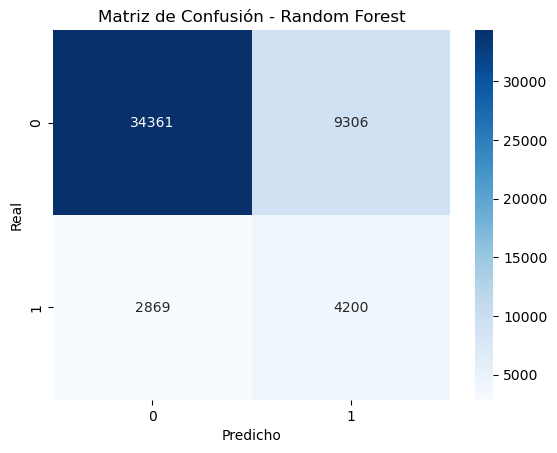


📊 Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     43667
           1       0.31      0.59      0.41      7069

    accuracy                           0.76     50736
   macro avg       0.62      0.69      0.63     50736
weighted avg       0.84      0.76      0.79     50736



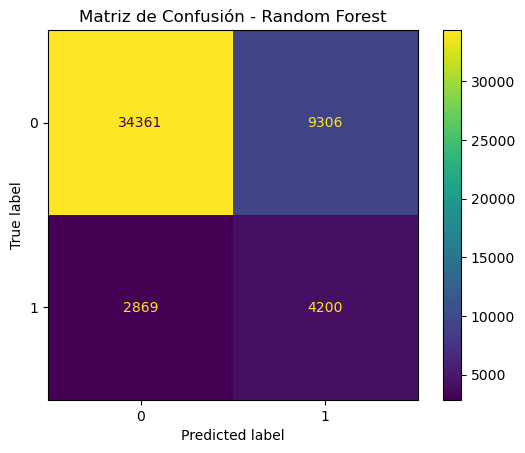

In [27]:
# Los resultados reales sobre los datos no vistos fueron:

best_models = {}
best_models["Random Forest"] = modelo_rf

# Evaluación
evaluate_model(
    modelo_rf,
    X_test,
    y_test,
    "Random Forest"
)

# Predicciones
pred_rf = modelo_rf.predict(X_test)

print("\n📊 Classification Report - Random Forest")
print(classification_report(y_test, pred_rf))

# Matriz de confusión
mat_conf = confusion_matrix(y_test, pred_rf)

ConfusionMatrixDisplay(mat_conf).plot()
plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [ ]:
# Para entrenar el mejor modelo:
# MEJOR MODELO RANDOM FOREST

RF_mejor = RandomForestClassifier(
    criterion=RF_mejor_vector_parametros[0],
    max_features=RF_mejor_vector_parametros[1],
    n_estimators=RF_mejor_vector_parametros[2],
    max_depth=RF_mejor_vector_parametros[3],
    random_state=42,
    n_jobs=-1
)

RF_mejor.fit(X_train_sm, y_train_sm)

pred_RF_mejor = RF_mejor.predict(X_test)

print("\n Classification Report - Random Forest")
print(classification_report(y_test, pred_RF_mejor))

# Guardar modelo
best_models['Random Forest'] = RF_mejor

# Evaluación con tu función
evaluate_model(RF_mejor, X_test, y_test, "Random Forest", results)

# Matriz de confusión
mat_conf = confusion_matrix(y_test, pred_RF_mejor)

ConfusionMatrixDisplay(mat_conf).plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

Y si quieres una versión más rápida, usa esta:

# RANDOM FOREST RÁPIDO

print("\n Entrenando Random Forest rápido...")

RF_mejor = RandomForestClassifier(
    n_estimators=150,
    criterion="gini",
    max_features="sqrt",
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

RF_mejor.fit(X_train_sm, y_train_sm)

best_models['Random Forest'] = RF_mejor

evaluate_model(RF_mejor, X_test, y_test, "Random Forest", results)

pred_RF = RF_mejor.predict(X_test)

print(classification_report(y_test, pred_RF))

mat_conf = confusion_matrix(y_test, pred_RF)
ConfusionMatrixDisplay(mat_conf).plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()


In [26]:
!pip install lightgbm
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
best_models = {}
# Instalar si hace falta:
# pip install xgboost lightgbm catboost

# Vamos a intentar que para todos los modelos haga esto de buscar cual es el mejor, en vez de usar el primero que sea

modelos_grid = {
    "XGBoost": {
        "modelo": XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),
        "params": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 4, 6],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    },

    "LightGBM": {
        "modelo": LGBMClassifier(
            random_state=42
        ),
        "params": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [-1, 3, 5],
            "num_leaves": [15, 31, 63],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    },

    "CatBoost": {
        "modelo": CatBoostClassifier(
            random_state=42,
            verbose=0
        ),
        "params": {
            "iterations": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "depth": [3, 4, 6],
            "l2_leaf_reg": [1, 3, 5]
        }
    }
}



mejores_modelos = {}
resultados = []

for nombre, config in modelos_grid.items():
    print(f"\nBuscando mejores parámetros para {nombre}...")

    grid = GridSearchCV(
        estimator=config["modelo"],
        param_grid=config["params"],
        cv=5,
        scoring="f1_weighted",   # puedes cambiar a "accuracy", "roc_auc", etc.
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    mejor_modelo = grid.best_estimator_
    mejores_modelos[nombre] = mejor_modelo

    y_pred = mejor_modelo.predict(X_test)

    resultados.append({
        "Modelo": nombre,
        "Mejores parámetros": grid.best_params_,
        "Mejor score CV": grid.best_score_,
        "Accuracy test": accuracy_score(y_test, y_pred)
    })

    print("Mejores parámetros:")
    print(grid.best_params_)

    print("\nResultados en test:")
    print(classification_report(y_test, y_pred))

df_resultados = pd.DataFrame(resultados)
df_resultados


Buscando mejores parámetros para XGBoost...
Mejores parámetros:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

Resultados en test:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43667
           1       0.55      0.17      0.26      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736


Buscando mejores parámetros para LightGBM...


### LGBM (LightBM)

In [24]:
# Sin hacer SMOTE a los datos:
lgbm = LGBMClassifier(
    random_state=42
)

param_lgbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31]
}

search_lgbm = RandomizedSearchCV(
    lgbm,
    param_distributions=param_lgbm,
    n_iter=3,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42
)

search_lgbm.fit(X_train, y_train)

best_lgbm = search_lgbm.best_estimator_

print("Mejores parámetros LightGBM:")
print(search_lgbm.best_params_)

y_pred_lgbm = best_lgbm.predict(X_test)

print(classification_report(y_test, y_pred_lgbm))
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 28277, number of negative: 174667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 201
[LightGBM] [Info] Number of data points in the train set: 202944, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.139334 -> initscore=-1.820833
[LightGBM] [Info] Start training from score -1.820833
Mejores parámetros LightGBM:
{'num_leaves': 31, 'n_estimators': 100, 'learning_rate': 0.1}
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43667
           1       0.56      0.16      0.25      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736

Accuracy: 0.86549984232

In [25]:
# Esto de aquí lo hago utilizando los datos despues de hacerles SMOTE.
lgbm = LGBMClassifier(
    random_state=42
)

param_lgbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31]
}

search_lgbm = RandomizedSearchCV(
    lgbm,
    param_distributions=param_lgbm,
    n_iter=3,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42
)

search_lgbm.fit(X_train_sm, y_train_sm)

best_lgbm = search_lgbm.best_estimator_

print("Mejores parámetros LightGBM:")
print(search_lgbm.best_params_)

y_pred_lgbm = best_lgbm.predict(X_test)

print(classification_report(y_test, y_pred_lgbm))
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 174667, number of negative: 174667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 349334, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Mejores parámetros LightGBM:
{'num_leaves': 31, 'n_estimators': 100, 'learning_rate': 0.1}
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     43667
           1       0.29      0.71      0.41      7069

    accuracy                           0.72     50736
   macro avg       0.61      0.71      0.61     50736
weighted avg       0.85      0.72      0.76     50736

Accuracy: 0.7203169347209082


### XGBoost

In [27]:
best_models={}

In [38]:
# Con los datos de SMOTE:
print("\n Entrenando XGBoost...")

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 6]
}

search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_xgb,
    n_iter=5,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Entrenamiento con SMOTE
search_xgb.fit(X_train, y_train)

best_xgb = search_xgb.best_estimator_
best_models["XGBoost"] = best_xgb

print("\nMejores parámetros:")
print(search_xgb.best_params_)

y_pred_xgb = best_xgb.predict(X_test)

print("\nResultados en test:")
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))


 Entrenando XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Mejores parámetros:
{'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}

Resultados en test:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43667
           1       0.56      0.17      0.26      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736

Accuracy: 0.8654801324503312


In [39]:
# Con los datos de SMOTE:
print("\n Entrenando XGBoost...")

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 6]
}

search_xgb_sm = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_xgb,
    n_iter=5,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Entrenamiento con SMOTE
search_xgb_sm.fit(X_train_sm, y_train_sm)

best_xgb_sm = search_xgb_sm.best_estimator_
best_models["XGBoost"] = best_xgb_sm

print("\nMejores parámetros:")
print(search_xgb_sm.best_params_)

y_pred_xgb = best_xgb_sm.predict(X_test)

print("\nResultados en test:")
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))


 Entrenando XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Mejores parámetros:
{'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}

Resultados en test:
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     43667
           1       0.29      0.70      0.41      7069

    accuracy                           0.72     50736
   macro avg       0.61      0.71      0.61     50736
weighted avg       0.85      0.72      0.76     50736

Accuracy: 0.7192328918322296


### CATBoost


 Entrenando CatBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mejores parámetros: {'learning_rate': 0.05, 'iterations': 200, 'depth': 6}

--- CatBoost ---
Accuracy: 0.8656
Precision: 0.5637
Recall: 0.1572
F1-Score: 0.2458
AUC-ROC: 0.8271

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     43667
           1       0.56      0.16      0.25      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736



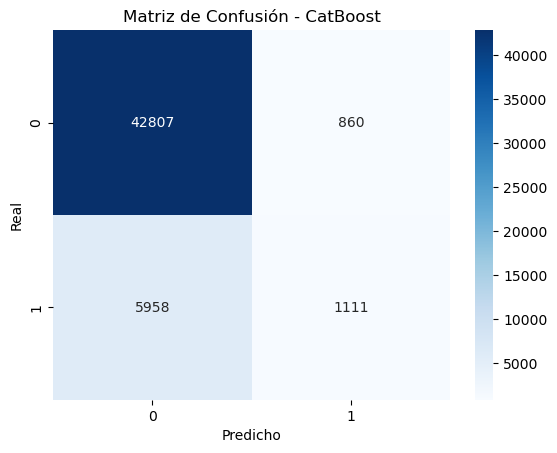

In [36]:
print("\n Entrenando CatBoost...")

cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

param_cat = {
    "iterations": [100, 200],
    "learning_rate": [0.05, 0.1],
    "depth": [3, 4, 6]
}

search_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_cat,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Entrenamiento con SMOTE
search_cat.fit(X_train, y_train)

modelo_cat = search_cat.best_estimator_

best_models["CatBoost"] = modelo_cat

print("Mejores parámetros:", search_cat.best_params_)

evaluate_model(
    modelo_cat,
    X_test,
    y_test,
    "CatBoost"
)


 Entrenando CatBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mejores parámetros: {'learning_rate': 0.1, 'iterations': 100, 'depth': 6}

--- CatBoost ---
Accuracy: 0.7186
Precision: 0.2917
Recall: 0.7142
F1-Score: 0.4143
AUC-ROC: 0.7875

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.72      0.81     43667
           1       0.29      0.71      0.41      7069

    accuracy                           0.72     50736
   macro avg       0.62      0.72      0.61     50736
weighted avg       0.85      0.72      0.76     50736



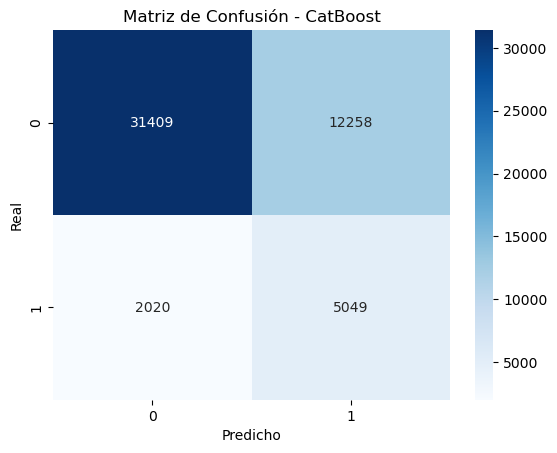

In [35]:
print("\n Entrenando CatBoost...")

cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

param_cat = {
    "iterations": [100, 200],
    "learning_rate": [0.05, 0.1],
    "depth": [3, 4, 6]
}

search_cat_sm = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_cat,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Entrenamiento con SMOTE
search_cat_sm.fit(X_train_sm, y_train_sm)

modelo_cat_sm = search_cat_sm.best_estimator_

best_models["CatBoost"] = modelo_cat_sm

print("Mejores parámetros:", search_cat_sm.best_params_)

evaluate_model(
    modelo_cat_sm,
    X_test,
    y_test,
    "CatBoost"
)

### MODELOS BASADOS EN DISTANCIAS

In [ ]:
# ==========================================
# PASO 2: Entrenar el Modelo con Datos Balanceados
# ==========================================

# ESTO ES LO PRIMERO QUE HICE YO

# Instanciar el modelo (puedes cambiar LogisticRegression por el que estés usando)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sm, y_train_sm)

# Predicción sobre el conjunto de TEST (que se mantuvo intacto)
y_pred_sm = model.predict(X_test)

### REGRESIÓN LOGISTICA


 Entrenando Regresión Logística...

--- Logistic Regression ---
Accuracy: 0.7213
Precision: 0.2893
Recall: 0.6871
F1-Score: 0.4072
AUC-ROC: 0.7790

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.73      0.82     43667
           1       0.29      0.69      0.41      7069

    accuracy                           0.72     50736
   macro avg       0.61      0.71      0.61     50736
weighted avg       0.84      0.72      0.76     50736



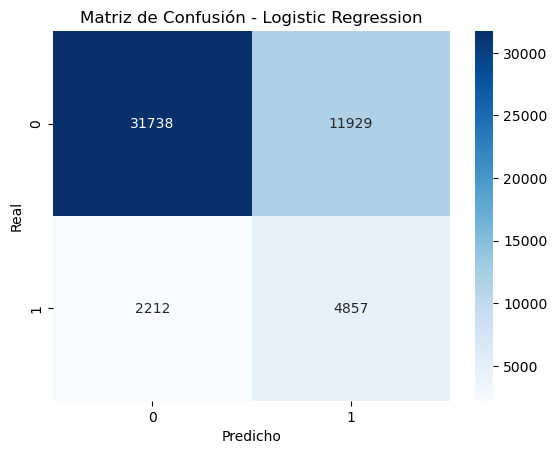

In [28]:
# REGRESIÓN LOGÍSTICA:
print("\n" + " Entrenando Regresión Logística...")

results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1': [],
    'AUC-ROC': []
}
best_models = {}

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Parámetros a probar
param_grid_lr = {'classifier__C': [0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(
    pipeline_lr, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_lr.fit(X_train_sm, y_train_sm)

# Mejor modelo
modelo_lr = grid_lr.best_estimator_


best_models['Logistic Regression'] = grid_lr.best_estimator_
evaluate_model(grid_lr.best_estimator_, X_test, y_test, "Logistic Regression")

### SVM


Entrenando con LinearSVC optimizado...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros:
{'clf__class_weight': None, 'clf__C': 0.1}

Resultados en test:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     43667
           1       0.56      0.07      0.12      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.53      0.52     50736
weighted avg       0.82      0.86      0.81     50736

Accuracy: 0.8626616209397666

--- SVM ---
Accuracy: 0.8627
Precision: 0.5573
Recall: 0.0695
F1-Score: 0.1235

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93     43667
           1       0.56      0.07      0.12      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.53      0.52     50736
weighted avg       0.82      0.86      0.81     50736



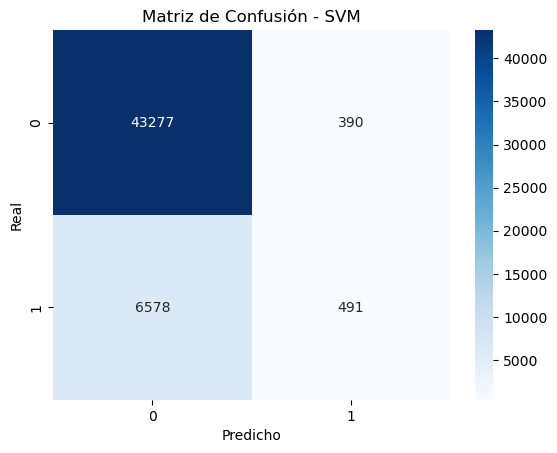

In [29]:
from sklearn.svm import LinearSVC
best_models={}
print("\nEntrenando con LinearSVC optimizado...")

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(
        random_state=42,
        max_iter=5000,
        dual="auto"
    ))
])

param_svm = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

search_svm = RandomizedSearchCV(
    estimator=pipeline_svm,
    param_distributions=param_svm,
    n_iter=20,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_svm.fit(X_train, y_train)

best_svm = search_svm.best_estimator_
best_models["SVM"] = best_svm

print("\nMejores parámetros:")
print(search_svm.best_params_)

y_pred_svm = best_svm.predict(X_test)

print("\nResultados en test:")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

evaluate_model(best_svm, X_test, y_test, "SVM")


Entrenando con LinearSVC optimizado...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros:
{'clf__class_weight': 'balanced', 'clf__C': 1}

Resultados en test:
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     43667
           1       0.29      0.69      0.41      7069

    accuracy                           0.72     50736
   macro avg       0.61      0.71      0.61     50736
weighted avg       0.85      0.72      0.76     50736

Accuracy: 0.7200804162724692

--- SVM ---
Accuracy: 0.7201
Precision: 0.2890
Recall: 0.6908
F1-Score: 0.4075

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.72      0.82     43667
           1       0.29      0.69      0.41      7069

    accuracy                           0.72     50736
   macro avg       0.61      0.71      0.61     50736
weighted avg       0.85      0.72      0.76     50736



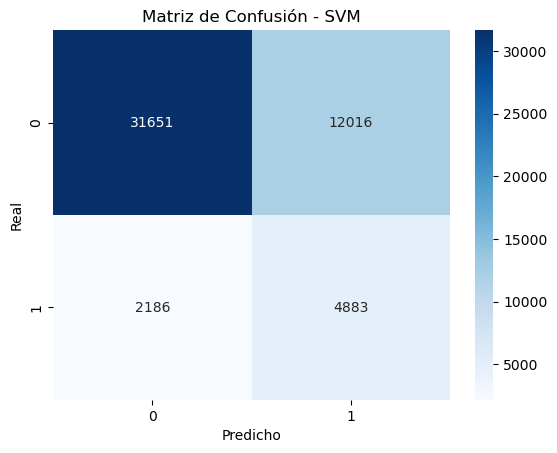

In [31]:
# 5.2 SVM
from sklearn.svm import LinearSVC
best_models={}
print("\nEntrenando con LinearSVC optimizado...")

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(
        random_state=42,
        max_iter=5000,
        dual="auto"
    ))
])

param_svm = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

search_svm_sm = RandomizedSearchCV(
    estimator=pipeline_svm,
    param_distributions=param_svm,
    n_iter=20,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_svm_sm.fit(X_train_sm, y_train_sm)

best_svm_sm = search_svm_sm.best_estimator_
best_models["SVM"] = best_svm_sm

print("\nMejores parámetros:")
print(search_svm_sm.best_params_)

y_pred_svm = best_svm_sm.predict(X_test)

print("\nResultados en test:")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

evaluate_model(best_svm_sm, X_test, y_test, "SVM")


 Entrenando KNN ultra optimizado...

Resultados en test:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92     43667
           1       0.41      0.21      0.28      7069

    accuracy                           0.85     50736
   macro avg       0.65      0.58      0.60     50736
weighted avg       0.82      0.85      0.83     50736

Accuracy: 0.8486676127404604

--- KNN ---
Accuracy: 0.8487
Precision: 0.4141
Recall: 0.2077
F1-Score: 0.2766
AUC-ROC: 0.7392

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92     43667
           1       0.41      0.21      0.28      7069

    accuracy                           0.85     50736
   macro avg       0.65      0.58      0.60     50736
weighted avg       0.82      0.85      0.83     50736



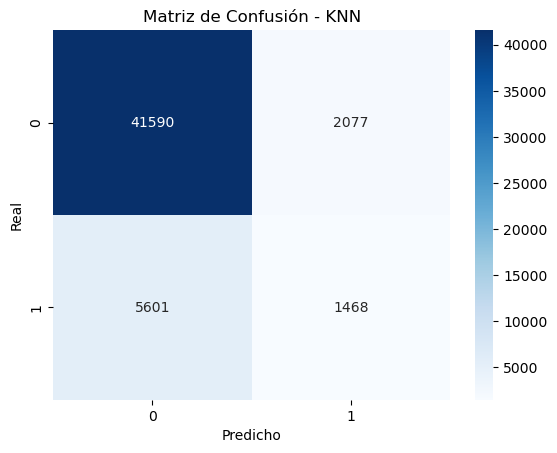

In [25]:
# 5.3 KNN ultra optimizado
print("\n Entrenando KNN ultra optimizado...")
best_models={}
modelo_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        metric="manhattan",
        algorithm="brute",
        n_jobs=-1
    ))
])

modelo_knn.fit(X_train, y_train)

best_models["KNN"] = modelo_knn

y_pred_knn = modelo_knn.predict(X_test)

print("\nResultados en test:")
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

evaluate_model(modelo_knn, X_test, y_test, "KNN")


 Entrenando KNN optimizado...
Fitting 2 folds for each of 6 candidates, totalling 12 fits

Mejores parámetros:
{'clf__n_neighbors': 7, 'clf__weights': 'uniform'}

Resultados en test:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     43667
           1       0.43      0.19      0.27      7069

    accuracy                           0.85     50736
   macro avg       0.66      0.58      0.59     50736
weighted avg       0.82      0.85      0.83     50736

Accuracy: 0.8520577105014191

--- KNN ---
Accuracy: 0.8521
Precision: 0.4312
Recall: 0.1937
F1-Score: 0.2673
AUC-ROC: 0.7436

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92     43667
           1       0.43      0.19      0.27      7069

    accuracy                           0.85     50736
   macro avg       0.66      0.58      0.59     50736
weighted avg       0.82      0.85      0.83     50736



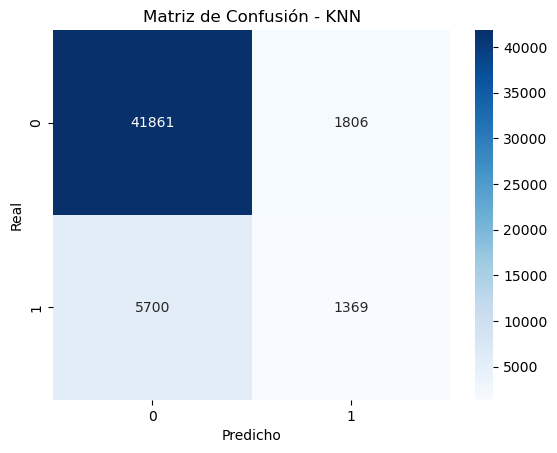

In [27]:
# 5.3 KNN optimizado intermedio
print("\n Entrenando KNN optimizado...")

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_jobs=-1))
])

param_knn = {
    "clf__n_neighbors": [5, 7, 9],
    "clf__weights": ["uniform", "distance"]
}

search_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_knn,
    cv=2,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

search_knn.fit(X_train, y_train)

modelo_knn = search_knn.best_estimator_

best_models["KNN"] = modelo_knn

print("\nMejores parámetros:")
print(search_knn.best_params_)

y_pred_knn = modelo_knn.predict(X_test)

print("\nResultados en test:")
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

evaluate_model(modelo_knn, X_test, y_test, "KNN")


 Entrenando Red Neuronal optimizada...
Fitting 2 folds for each of 6 candidates, totalling 12 fits

Mejores parámetros Red Neuronal:
{'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (50,), 'clf__alpha': 0.001, 'clf__activation': 'tanh'}

Resultados en test:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43667
           1       0.54      0.15      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736

Accuracy: 0.864120151371807

--- Neural Network ---
Accuracy: 0.8641
Precision: 0.5443
Recall: 0.1519
F1-Score: 0.2376
AUC-ROC: 0.8243

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     43667
           1       0.54      0.15      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.71

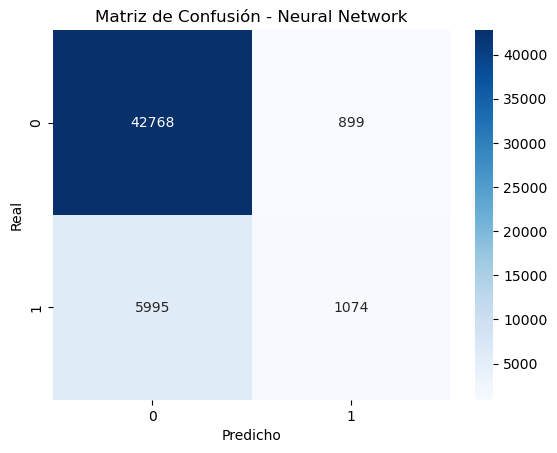

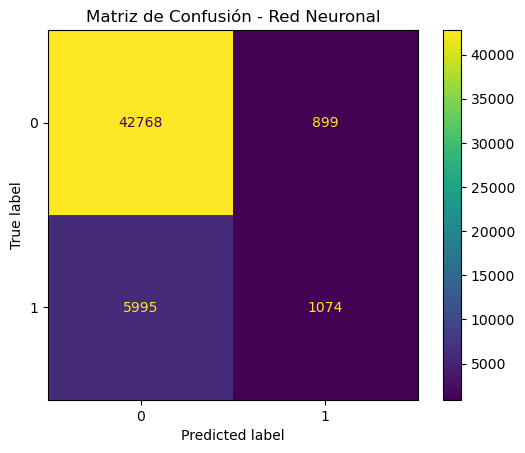

In [28]:
# 5.4 Red Neuronal optimizada
print("\n Entrenando Red Neuronal optimizada...")

from sklearn.neural_network import MLPClassifier

pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        max_iter=300,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=10
    ))
])

param_mlp = {
    "clf__hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": [0.0001, 0.001],
    "clf__learning_rate_init": [0.001, 0.01]
}

search_mlp = RandomizedSearchCV(
    estimator=pipeline_mlp,
    param_distributions=param_mlp,
    n_iter=6,
    cv=2,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_mlp.fit(X_train, y_train)

modelo_mlp = search_mlp.best_estimator_
best_models["Neural Network"] = modelo_mlp

print("\nMejores parámetros Red Neuronal:")
print(search_mlp.best_params_)

y_pred_mlp = modelo_mlp.predict(X_test)

print("\nResultados en test:")
print(classification_report(y_test, y_pred_mlp))
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))

evaluate_model(modelo_mlp, X_test, y_test, "Neural Network")

mat_conf = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(mat_conf).plot()
plt.title("Matriz de Confusión - Red Neuronal")
plt.show()


 Entrenando Red Neuronal optimizada...
Fitting 2 folds for each of 6 candidates, totalling 12 fits

Mejores parámetros Red Neuronal:
{'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (50, 50), 'clf__alpha': 0.0001, 'clf__activation': 'tanh'}

Resultados en test:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     43667
           1       0.28      0.70      0.40      7069

    accuracy                           0.70     50736
   macro avg       0.61      0.70      0.60     50736
weighted avg       0.84      0.70      0.75     50736

Accuracy: 0.7031299274676758

--- Neural Network ---
Accuracy: 0.8641
Precision: 0.5443
Recall: 0.1519
F1-Score: 0.2376
AUC-ROC: 0.8243

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     43667
           1       0.54      0.15      0.24      7069

    accuracy                           0.86     50736
   macro avg      

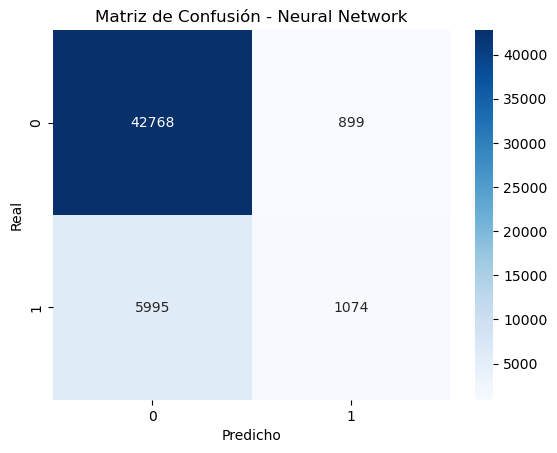

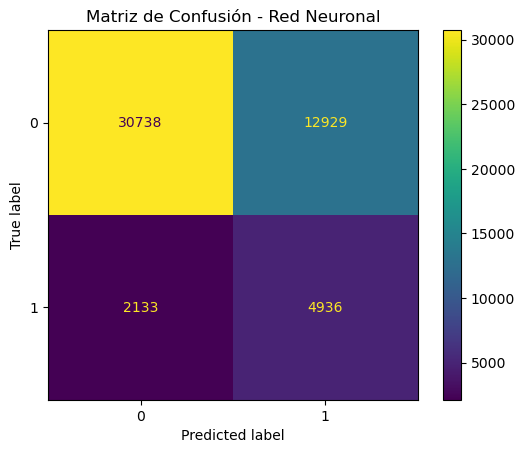

In [29]:
# 5.4 Red Neuronal optimizada
print("\n Entrenando Red Neuronal optimizada...")

from sklearn.neural_network import MLPClassifier

pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        max_iter=300,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=10
    ))
])

param_mlp = {
    "clf__hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": [0.0001, 0.001],
    "clf__learning_rate_init": [0.001, 0.01]
}

search_mlp_sm = RandomizedSearchCV(
    estimator=pipeline_mlp,
    param_distributions=param_mlp,
    n_iter=6,
    cv=2,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_mlp_sm.fit(X_train_sm, y_train_sm)

modelo_mlp_sm = search_mlp_sm.best_estimator_
best_models["Neural Network"] = modelo_mlp_sm

print("\nMejores parámetros Red Neuronal:")
print(search_mlp_sm.best_params_)

y_pred_mlp = modelo_mlp_sm.predict(X_test)

print("\nResultados en test:")
print(classification_report(y_test, y_pred_mlp))
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))

evaluate_model(modelo_mlp, X_test, y_test, "Neural Network")

mat_conf = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(mat_conf).plot()
plt.title("Matriz de Confusión - Red Neuronal")
plt.show()

In [30]:
# Diagnóstico de un nuevo paciente

nombre_v = input("Introduce el nombre o identificador del paciente: ")

pac = [
    int(input("Género (0=mujer, 1=hombre): ")),
    float(input("Edad en años: ")),
    float(input("Altura en metros: ")),
    float(input("Peso en kg: ")),
    int(input("¿Antecedentes familiares? (0=no, 1=sí): ")),
    int(input("¿Consume comida altamente calórica? (0=no, 1=sí): ")),
    float(input("Cantidad de verduras semanales: ")),
    float(input("Cantidad de comidas diarias: ")),
    int(input("¿Come entre horas? (0=nunca, 1=a veces, 2=frecuentemente, 3=siempre): ")),
    int(input("¿Fuma? (0=no, 1=sí): ")),
    float(input("Litros de agua diarios: ")),
    int(input("¿Monitoriza calorías? (0=no, 1=sí): ")),
    float(input("Días semanales de actividad física: ")),
    float(input("Horas diarias de uso de tecnología: ")),
    int(input("¿Alcohol? (0=nunca, 1=a veces, 2=frecuentemente, 3=siempre): ")),
    int(input("Transporte habitual (1=público, 2=a pie, 3=automóvil, 4=moto, 5=bicicleta): "))
]

columnas = [
    "genero", "edad", "altura", "peso", "hist_fam", "alta_cal_frec",
    "verduras", "num_comidas", "entrehoras", "fumar", "agua_dia",
    "monit_cal", "act_fis", "uso_tecn", "alcohol", "transporte"
]

pac_df = pd.DataFrame([pac], columns=columnas)

def diag_nom(diagnostico):
    nombres = {
        0: "insuficiente",
        1: "normal",
        2: "sobrepeso 1",
        3: "sobrepeso 2",
        4: "obesidad 1",
        5: "obesidad 2",
        6: "obesidad 3"
    }
    return nombres.get(int(diagnostico), "desconocido")


diagnosticos = []

for nombre_modelo, modelo in best_models.items():
    pred = modelo.predict(pac_df)[0]

    diagnosticos.append({
        "Método": nombre_modelo,
        "Diagnóstico": int(pred),
        "Diagnóstico_nombre": diag_nom(pred)
    })

df_diagnostico = pd.DataFrame(diagnosticos)

df_datos = pd.DataFrame({
    "medida": columnas,
    "valor": pac
})

df_nombre = pd.DataFrame({
    "nombre": [nombre_v]
})

display(df_diagnostico)

df_datos.to_csv("datospac_obesidad_py.csv", index=False)
df_diagnostico.to_csv("diagnostico_obesidad_py.csv", index=False)
df_nombre.to_csv("nombrepac_obesidad_py.csv", index=False)

Introduce el nombre o identificador del paciente:  leire
Género (0=mujer, 1=hombre):  0
Edad en años:  23
Altura en metros:  178
Peso en kg:  60
¿Antecedentes familiares? (0=no, 1=sí):  0
¿Consume comida altamente calórica? (0=no, 1=sí):  1
Cantidad de verduras semanales:  3
Cantidad de comidas diarias:  4
¿Come entre horas? (0=nunca, 1=a veces, 2=frecuentemente, 3=siempre):  3
¿Fuma? (0=no, 1=sí):  1
Litros de agua diarios:  0
¿Monitoriza calorías? (0=no, 1=sí):  0
Días semanales de actividad física:  0
Horas diarias de uso de tecnología:  50
¿Alcohol? (0=nunca, 1=a veces, 2=frecuentemente, 3=siempre):  3
Transporte habitual (1=público, 2=a pie, 3=automóvil, 4=moto, 5=bicicleta):  4


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- act_fis
- agua_dia
- alcohol
- alta_cal_frec
- altura
- ...
Feature names seen at fit time, yet now missing:
- Age
- AnyHealthcare
- BMI
- CholCheck
- DiffWalk
- ...


In [ ]:
#box plot for outlier visualization
sns.set(style="whitegrid")
df.boxplot(figsize=(15,6))

In [ ]:
#box plot
sns.set(style="whitegrid")

sns.set(rc={'figure.figsize':(4,2)})
sns.boxplot(x=df['Insulin'])
plt.show()
sns.boxplot(x=df['BloodPressure'])
plt.show()
sns.boxplot(x=df['DiabetesPedigreeFunction'])
plt.show()

In [ ]:
#outlier remove

Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1

print("---Q1--- \n",Q1)
print("\n---Q3--- \n",Q3)
print("\n---IQR---\n",IQR)

#print((df < (Q1 - 1.5 * IQR))|(df > (Q3 + 1.5 * IQR)))


In [ ]:
#outlier remove
df_out = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]
df.shape,df_out.shape
#more than 80 records deleted

In [ ]:
#Scatter matrix after removing outlier
sns.set(style="ticks")
sns.pairplot(df_out, hue="Outcome")
plt.show()

In [ ]:
#lets extract features and targets
X=df_out.drop(columns=['Outcome'])
y=df_out['Outcome']

In [ ]:
#Splitting train test data 80 20 ratio
from sklearn.model_selection import train_test_split
train_X,test_X,train_y,test_y=train_test_split(X,y,test_size=0.2)

In [ ]:
train_X.shape,test_X.shape,train_y.shape,test_y.shape

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,make_scorer
from sklearn.model_selection import cross_validate

def tn(y_true, y_pred): return confusion_matrix(y_true, y_pred)[0, 0]
def fp(y_true, y_pred): return confusion_matrix(y_true, y_pred)[0, 1]
def fn(y_true, y_pred): return confusion_matrix(y_true, y_pred)[1, 0]
def tp(y_true, y_pred): return confusion_matrix(y_true, y_pred)[1, 1]

#cross validation purpose
scoring = {'accuracy': make_scorer(accuracy_score),'prec': 'precision'}
scoring = {'tp': make_scorer(tp), 'tn': make_scorer(tn),
           'fp': make_scorer(fp), 'fn': make_scorer(fn)}

def display_result(result):
    print("TP: ",result['test_tp'])
    print("TN: ",result['test_tn'])
    print("FN: ",result['test_fn'])
    print("FP: ",result['test_fp'])

In [ ]:
# Para construir el modelo:

# Regresión Logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

acc=[]
roc=[]

clf=LogisticRegression()
clf.fit(train_X,train_y)
y_pred=clf.predict(test_X)
#find accuracy
ac=accuracy_score(test_y,y_pred)
acc.append(ac)

#find the ROC_AOC curve
rc=roc_auc_score(test_y,y_pred)
roc.append(rc)
print("\nAccuracy {0} ROC {1}".format(ac,rc))

#cross val score
result=cross_validate(clf,train_X,train_y,scoring=scoring,cv=10)
display_result(result)

#display predicted values uncomment below line
#pd.DataFrame(data={'Actual':test_y,'Predicted':y_pred}).head()

In [ ]:
#Support Vector Machine
from sklearn.svm import SVC

clf=SVC(kernel='linear')
clf.fit(train_X,train_y)
y_pred=clf.predict(test_X)
#find accuracy
ac=accuracy_score(test_y,y_pred)
acc.append(ac)

#find the ROC_AOC curve
rc=roc_auc_score(test_y,y_pred)
roc.append(rc)
print("\nAccuracy {0} ROC {1}".format(ac,rc))

#cross val score
result=cross_validate(clf,train_X,train_y,scoring=scoring,cv=10)
display_result(result)

#display predicted values uncomment below line
#pd.DataFrame(data={'Actual':test_y,'Predicted':y_pred}).head()

In [ ]:
#KNN

from sklearn.neighbors import KNeighborsClassifier

clf=KNeighborsClassifier(n_neighbors=3)
clf.fit(train_X,train_y)
y_pred=clf.predict(test_X)
#find accuracy
ac=accuracy_score(test_y,y_pred)
acc.append(ac)

#find the ROC_AOC curve
rc=roc_auc_score(test_y,y_pred)
roc.append(rc)
print("\nAccuracy {0} ROC {1}".format(ac,rc))

#cross val score
result=cross_validate(clf,train_X,train_y,scoring=scoring,cv=10)
display_result(result)

#display predicted values uncomment below line
#pd.DataFrame(data={'Actual':test_y,'Predicted':y_pred}).head()

In [ ]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

clf=RandomForestClassifier()
clf.fit(train_X,train_y)

y_pred=clf.predict(test_X)
#find accuracy
ac=accuracy_score(test_y,y_pred)
acc.append(ac)

#find the ROC_AOC curve
rc=roc_auc_score(test_y,y_pred)
roc.append(rc)
print("\nAccuracy {0} ROC {1}".format(ac,rc))

#cross val score
result=cross_validate(clf,train_X,train_y,scoring=scoring,cv=10)
display_result(result)

#display predicted values uncomment below line
#pd.DataFrame(data={'Actual':test_y,'Predicted':y_pred}).head()

In [ ]:
#Naive Bayes Theorem
#import library
from sklearn.naive_bayes import GaussianNB

clf=GaussianNB()
clf.fit(train_X,train_y)
y_pred=clf.predict(test_X)
#find accuracy
ac=accuracy_score(test_y,y_pred)
acc.append(ac)

#find the ROC_AOC curve
rc=roc_auc_score(test_y,y_pred)
roc.append(rc)
print("\nAccuracy {0} ROC {1}".format(ac,rc))

#cross val score
result=cross_validate(clf,train_X,train_y,scoring=scoring,cv=10)
display_result(result)

#display predicted values uncomment below line
#pd.DataFrame(data={'Actual':test_y,'Predicted':y_pred}).head()

In [ ]:
#Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
clf=GradientBoostingClassifier(n_estimators=50,learning_rate=0.2)
clf.fit(train_X,train_y)
y_pred=clf.predict(test_X)
#find accuracy
ac=accuracy_score(test_y,y_pred)
acc.append(ac)

#find the ROC_AOC curve
rc=roc_auc_score(test_y,y_pred)
roc.append(rc)
print("\nAccuracy {0} ROC {1}".format(ac,rc))

#cross val score
result=cross_validate(clf,train_X,train_y,scoring=scoring,cv=10)
display_result(result)

#display predicted values uncomment below line
#pd.DataFrame(data={'Actual':test_y,'Predicted':y_pred}).head()

In [ ]:
#lets plot the bar graph

ax=plt.figure(figsize=(9,4))
plt.bar(['Logistic Regression','SVM','KNN','Random Forest','Naivye Bayes','Gradient Boosting'],acc,label='Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Algortihms')
plt.show()

ax=plt.figure(figsize=(9,4))
plt.bar(['Logistic Regression','SVM','KNN','Random Forest','Naivye Bayes','Gradient Boosting'],roc,label='ROC AUC')
plt.ylabel('ROC AUC')
plt.xlabel('Algortihms')
plt.show()

In [ ]:
#Great....
#Random forest has highest accuracy 98% and ROC_AUC curve 97%
#model can be improve more if we take same count of labels
#in our model 30% is diabetic and 70% no diabetic patient

#model can be improve with fine tunning